# Module 07 Lab - Better Model Evaluation**Objective:** To move beyond simple accuracy and learn how to use more sophisticated and reliable evaluation techniques, including the confusion matrix, precision, recall, and cross-validation.**In this lab, you will write the code to generate and interpret these advanced evaluation metrics.**

In [1]:
#@title Part 0: Check GPU Status
import subprocess
simple_nvidia_smi_display = True#@param {type:"boolean"}
if simple_nvidia_smi_display:
    #!nvidia-smi
    nvidiasmi_output = subprocess.run(['nvidia-smi', '-L'], stdout=subprocess.PIPE).stdout.decode('utf-8')
    print(nvidiasmi_output)
else:
    #!nvidia-smi -i 0 -e 0
    nvidiasmi_output = subprocess.run(['nvidia-smi'], stdout=subprocess.PIPE).stdout.decode('utf-8')
    print(nvidiasmi_output)
    nvidiasmi_ecc_note = subprocess.run(['nvidia-smi', '-i', '0', '-e', '0'], stdout=subprocess.PIPE).stdout.decode('utf-8')
    print(nvidiasmi_ecc_note)

GPU 0: Tesla T4 (UUID: GPU-ad600375-0077-bb4e-1640-f078ad22a239)



## Part 1: Setup and Model TrainingLet's first train a model so we have something to evaluate. We will use the Titanic dataset again to predict survival.

In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

# Load and prepare data
df = pd.read_csv('https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv')
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})
#df['Age'].fillna(df['Age'].median(), inplace=True)
df['Age'] = df['Age'].fillna(df['Age'].median())

features = ['Age', 'Pclass', 'Sex', 'Fare']
target = 'Survived'

X = df[features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train a model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

💡 **Nota Bene:** The original notebook file had formatting issues where code cells collapsed into a single line, so I opened it in VS Code to view and copy the code correctly into Google Colab.

💡 **Nota Bene:** I got the following error:

/tmp/ipykernel_885/4265675851.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(), inplace=True)


💡 **Nota Bene:** I replaced the line of code `df[‘Age’].fillna(df[‘Age’].median(), inplace=True)` with `df[‘Age’] = df[‘Age’].fillna(df[‘Age’].median())`

In [3]:
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",0,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",1,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",0,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",0,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",1,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",1,28.0,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",0,26.0,0,0,111369,30.0000,C148,C


💡 **Nota Bene:** I added the df command in a separate cell to inspect the dataset before moving to the next code block.

## Part 2: The Confusion Matrix**Concept:** A confusion matrix gives you a more detailed breakdown of a model's performance than accuracy alone. It's a table that shows you where your model got things right and where it got them wrong.It has four quadrants:*   **True Positives (TP):** Correctly predicted positive (e.g., predicted survival, and they did survive).*   **True Negatives (TN):** Correctly predicted negative (e.g., predicted did not survive, and they did not).*   **False Positives (FP):** Incorrectly predicted positive (e.g., predicted survival, but they did not). Also called a "Type I Error".*   **False Negatives (FN):** Incorrectly predicted negative (e.g., predicted did not survive, but they did). Also called a "Type II Error".

### Task 1: Generate and Plot a Confusion Matrix**Your Task:** Use `confusion_matrix` from `sklearn.metrics` to calculate the matrix and `seaborn.heatmap` to visualize it.

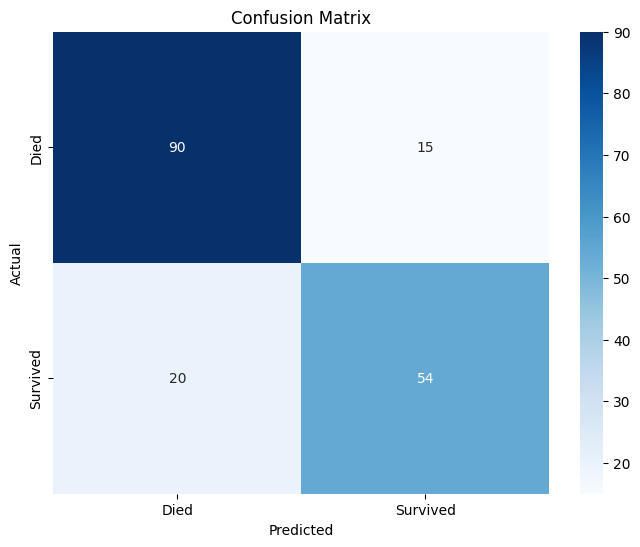

In [4]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# --- ENTER MY CODE HERE ---

# 1. Calculate the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# 2. Create a heatmap to visualize it
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Died', 'Survived'], yticklabels=['Died', 'Survived'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

💡 **Nota Bene:** The model is incorrect in 14% of cases for those who died and in 27% of cases for those who survived

💡 **Nota Bene:** The model's accuracy for the 'died' is 0.86; the model's accuracy for 'survived' is 0.73

## Part 3: Precision, Recall, and F1-Score**Concept:** From the confusion matrix, we can calculate more nuanced metrics:*   **Precision:** Of all the times the model predicted **positive**, how often was it correct?     *   Formula: `TP / (TP + FP)`    *   *Use Case:* When the cost of a **False Positive** is high. (e.g., a spam filter; you don't want to incorrectly mark an important email as spam).*   **Recall (Sensitivity):** Of all the actual **positives**, how many did the model correctly identify?    *   Formula: `TP / (TP + FN)`    *   *Use Case:* When the cost of a **False Negative** is high. (e.g., a medical test for a serious disease; you don't want to miss a real case).*   **F1-Score:** The harmonic mean of Precision and Recall. It provides a single score that balances both.

### Task 2: Generate a Classification Report**Your Task:** Use `classification_report` from `sklearn.metrics` to get a summary of these metrics for each class.

In [5]:
from sklearn.metrics import classification_report

# --- ENTER MY CODE HERE ---

# 1. Generate and print the classification report
report = classification_report(y_test, y_pred)
print(report)

              precision    recall  f1-score   support

           0       0.82      0.86      0.84       105
           1       0.78      0.73      0.76        74

    accuracy                           0.80       179
   macro avg       0.80      0.79      0.80       179
weighted avg       0.80      0.80      0.80       179



💡 **Nota Bene:** It seems to me that 'recall' = 'accuracy' for each class; what I referred to as 'accuracy' in my previous comment is called 'recall' here.

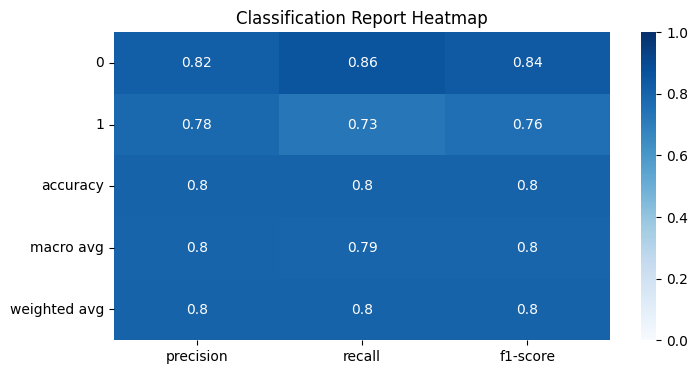

In [7]:
report_dict = classification_report(y_test, y_pred, output_dict=True)


df_report = pd.DataFrame(report_dict).iloc[:-1, :].T

plt.figure(figsize=(8, 4))
sns.heatmap(df_report, annot=True, cmap='Blues', vmin=0, vmax=1)
plt.title('Classification Report Heatmap')
plt.show()

💡 **Nota Bene:** At first sight, it seems that the model's accuracy is the average of the recall values, but this needs to be double-checked, since ‘recall/macro avg’ is 0.79, unlike all the other values, which are 0.8

## Part 4: Cross-Validation**Concept:** A single train-test split can be lucky or unlucky. What if, by chance, all the "easy" examples ended up in our test set? Our accuracy score would be misleadingly high.**Cross-Validation (CV)** solves this. It splits the data into multiple "folds" (e.g., 5 or 10). It then trains and evaluates the model multiple times, using a different fold as the test set each time. The final score is the average of the scores from all folds.This gives a much more robust and reliable estimate of the model's true performance.

### Task 3: Perform Cross-Validation**Your Task:** Use `cross_val_score` from `sklearn.model_selection` to perform 5-fold cross-validation on your model.

In [6]:
from sklearn.model_selection import cross_val_score

# --- ENTER MY CODE HERE ---

# 1. Perform 5-fold cross-validation
#    Note: We use the *entire* dataset (X, y) here, as cross_val_score handles the splitting internally.
cv_scores = cross_val_score(model, X, y, cv=5)

# 2. Print the scores for each fold and the average score
print(f"Scores for each fold: {cv_scores}")
print(f"Average CV Score: {cv_scores.mean():.2%}")
print(f"Standard Deviation of CV Scores: {cv_scores.std():.4f}")

Scores for each fold: [0.7877095  0.78089888 0.78651685 0.7752809  0.80337079]
Average CV Score: 78.68%
Standard Deviation of CV Scores: 0.0094


💡 **Nota Bene:** I want to visualize it graphically again

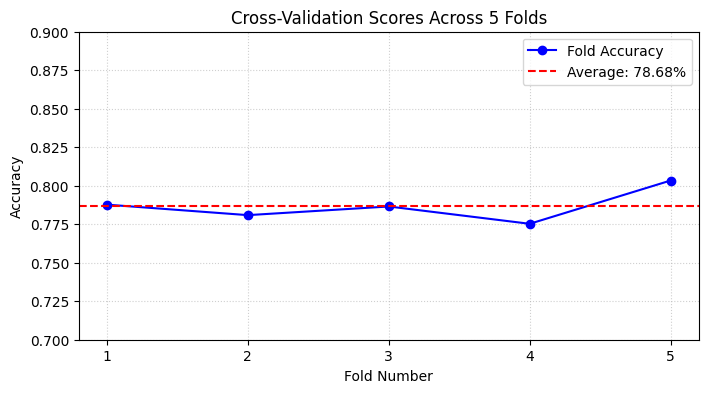

In [8]:
plt.figure(figsize=(8, 4))
plt.plot(range(1, 6), cv_scores, marker='o', linestyle='-', color='b', label='Fold Accuracy')
plt.axhline(y=cv_scores.mean(), color='r', linestyle='--', label=f'Average: {cv_scores.mean():.2%}')

plt.xlabel('Fold Number')
plt.ylabel('Accuracy')
plt.title('Cross-Validation Scores Across 5 Folds')
plt.xticks([1, 2, 3, 4, 5])
plt.ylim(0.7, 0.9)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

💡 **Nota Bene:**  In this lab, I got a very strange result, as if the model's trainability didn't depend on the training set, I understand that in the ITAI-1378-Comp Vision course, the model was highly dependent on the training data, and when the model was retrained, the accuracy varied over a very wide range; however, in that context, this was also explained by the various random weights that were set at the beginning of each retraining run.

## 📝 Knowledge Check**Instructions:** Answer the following questions in this markdown cell.1.  **Describe a real-world scenario where you would care more about a model's Precision than its Recall.**2.  **Describe a real-world scenario where you would care more about a model's Recall than its Precision.**3.  **Why is a cross-validation score generally more trustworthy than a score from a single train-test split?

1. One good example for high precision is one spam email filter. You want to stop spam messages. But you must not delete one important email from your boss. You prefer to see some spam in your inbox to protect good emails. False alarms cause big problems here.

2. One good example for high recall is one sickness scan in hospitals. You want to find every sick patient. Some healthy people receive one false alarm. This thing is fine. Doctors can do more tests later. But if you miss one real sick person, that patient suffers. Missing targets is very bad here.

3. One single test split gives one random score. That single score changes very easily. Cross-validation is trusted more because that data is cut into many equal parts (5 in this lab). The model attempts to predict every part. We calculate one average from all scores. In my Computer Vision class, neural network scores jump heavily because random starting weights change. But this Logistic Regression model shows very stable scores across all. This cross-validation proves this model learns real data rules.

